In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
df_model = pd.read_csv(
    "../data/telco_churn_feature_engineered.csv"
)

In [3]:
df_model.shape

(7043, 25)

In [6]:
df_model.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,charge_diff,tenure_group,service_count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,0.000000,New (0-1yr),1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,55.573529,1.376471,Mid (1-4yr),2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,-0.225000,New (0-1yr),2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,1.394444,Mid (1-4yr),3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,-5.125000,New (0-1yr),0


In [5]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   str    
 1   gender             7043 non-null   str    
 2   SeniorCitizen      7043 non-null   int64  
 3   Partner            7043 non-null   str    
 4   Dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   PhoneService       7043 non-null   str    
 7   MultipleLines      7043 non-null   str    
 8   InternetService    7043 non-null   str    
 9   OnlineSecurity     7043 non-null   str    
 10  OnlineBackup       7043 non-null   str    
 11  DeviceProtection   7043 non-null   str    
 12  TechSupport        7043 non-null   str    
 13  StreamingTV        7043 non-null   str    
 14  StreamingMovies    7043 non-null   str    
 15  Contract           7043 non-null   str    
 16  PaperlessBilling   7043 non-null   

In [11]:
df_model.isnull().sum().sum()

np.int64(0)

Saparate X and y

In [12]:
X=df_model.drop(columns=['Churn'])
y=df_model['Churn']

In [13]:
X.shape

(7043, 24)

In [14]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5634, 24)
Testing: (1409, 24)


In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [19]:
logistic_model.fit(X_train, y_train)

ValueError: could not convert string to float: '4950-BDEUX'

In [20]:
X_train.dtypes

customerID               str
gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies          str
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
avg_monthly_spend    float64
charge_diff          float64
tenure_group             str
service_count          int64
dtype: object

In [21]:
X_train.select_dtypes(include=['object']).columns.tolist()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17632\79599293.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include=['object']).columns.tolist()


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'tenure_group']

In [22]:
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [23]:
X_train.select_dtypes(include=['object']).columns.tolist()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17632\79599293.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include=['object']).columns.tolist()


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'tenure_group']

In [24]:
print("X_train missing:", X_train.isnull().sum().sum())
print("X_test missing:", X_test.isnull().sum().sum())

X_train missing: 0
X_test missing: 0


In [25]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

ValueError: could not convert string to float: '4950-BDEUX'

In [26]:
print(y_train.dtype)
print(y_train.unique())

str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [27]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [28]:
print(X_train.select_dtypes(include=['object']).columns.tolist())

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


C:\Users\Hp\AppData\Local\Temp\ipykernel_17632\3912895484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object']).columns.tolist())


In [29]:
bool_cols = X_train.select_dtypes(include=['bool']).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [30]:
print(X_train.dtypes.value_counts())

str        17
float64     4
int64       3
Name: count, dtype: int64


In [31]:
print("X_train missing:", X_train.isnull().sum().sum())
print("X_test missing:", X_test.isnull().sum().sum())
print("y_train missing:", y_train.isnull().sum())
print("y_test missing:", y_test.isnull().sum())

X_train missing: 0
X_test missing: 0
y_train missing: 0
y_test missing: 0


In [32]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

ValueError: could not convert string to float: '4950-BDEUX'

In [33]:
print("X object columns:", X_train.select_dtypes(include=['object']).columns.tolist())
print("X dtypes:", X_train.dtypes.value_counts())
print("y values:", y_train.unique())

X object columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
X dtypes: str        17
float64     4
int64       3
Name: count, dtype: int64
y values: [0 1]


C:\Users\Hp\AppData\Local\Temp\ipykernel_17632\2662978461.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("X object columns:", X_train.select_dtypes(include=['object']).columns.tolist())


In [35]:
X_train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,avg_monthly_spend,charge_diff,tenure_group,service_count
3738,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,Month-to-month,No,Electronic check,49.20,1701.65,48.618571,0.581429,Mid (1-4yr),3
3151,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,Month-to-month,No,Mailed check,75.10,1151.55,76.770000,-1.670000,Mid (1-4yr),1
4860,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Two year,No,Mailed check,40.55,590.35,45.411538,-4.861538,Mid (1-4yr),3
3867,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,73.296154,0.203846,Mid (1-4yr),4
3810,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,Month-to-month,No,Electronic check,44.55,44.55,44.550000,0.000000,New (0-1yr),0


In [37]:
print(X_train.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charge_diff', 'tenure_group', 'service_count']


In [38]:
X_train = X_train.drop(columns=['customerID'], errors='ignore')
X_test = X_test.drop(columns=['customerID'], errors='ignore')

In [39]:
print(X_train.select_dtypes(include='object').columns.tolist())

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


C:\Users\Hp\AppData\Local\Temp\ipykernel_17632\2968373797.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include='object').columns.tolist())


In [40]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [41]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [42]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [43]:
print(X_train.dtypes.value_counts())

float64    35
Name: count, dtype: int64


In [44]:
print(X_train.select_dtypes(include='object').columns.tolist())

[]


In [45]:
print(y_train.unique())

[0 1]


In [46]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [47]:
y_pred = logistic_model.predict(X_test)

In [48]:
print(y_pred[:10])

[0 1 0 0 0 1 0 0 0 0]


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8005677785663591

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[932 103]
 [178 196]]


Predictions

In [50]:
y_pred=logistic_model.predict(X_test)

In [51]:
print(y_pred[:10])

[0 1 0 0 0 1 0 0 0 0]


In [52]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8005677785663591


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[932 103]
 [178 196]]


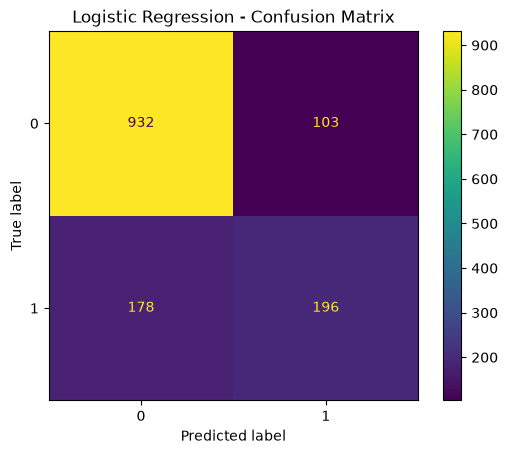

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [58]:
import joblib

joblib.dump(logistic_model, "logistic_regression_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [61]:
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [62]:
rf_pred = random_forest.predict(X_test)

In [63]:
print(rf_pred[:10])

[0 1 0 0 0 0 0 0 0 0]


In [64]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7877927608232789


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [66]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.8005677785663591
Random Forest Accuracy: 0.7877927608232789


In [67]:
print("Model Comparison")
print("-------------------------")
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Model Comparison
-------------------------
Logistic Regression Accuracy: 0.8005677785663591
Random Forest Accuracy: 0.7877927608232789


In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Logistic Regression")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nRandom Forest")
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Logistic Regression
Precision: 0.6555183946488294
Recall: 0.5240641711229946
F1 Score: 0.5824665676077266

Random Forest
Precision: 0.6279863481228669
Recall: 0.4919786096256685
F1 Score: 0.5517241379310345


In [69]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.800568,0.655518,0.524064,0.582467
1,Random Forest,0.787793,0.627986,0.491979,0.551724


In [70]:
best_model = comparison.loc[comparison["F1 Score"].idxmax(), "Model"]

print("Best Model:", best_model)

Best Model: Logistic Regression


In [71]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_forest.feature_importances_
})

In [72]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [73]:
feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.128831
1,tenure,0.114100
2,MonthlyCharges,0.112631
4,avg_monthly_spend,0.111762
5,charge_diff,0.089668
34,tenure_group_New (0-1yr),0.035602
31,PaymentMethod_Electronic check,0.035337
13,InternetService_Fiber optic,0.033280
6,service_count,0.030917
28,Contract_Two year,0.028455


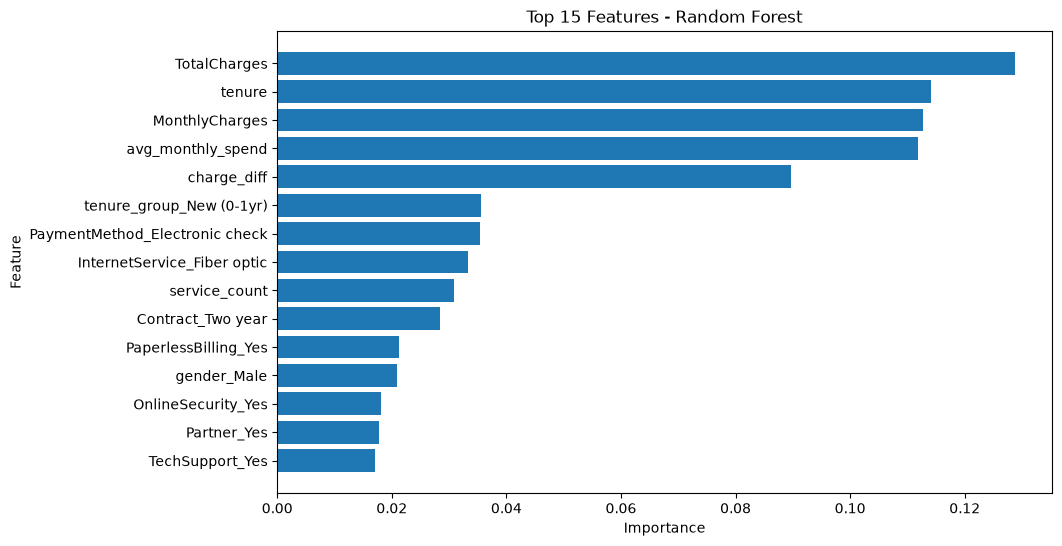

In [74]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.show()

In [75]:
feature_importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

In [76]:
!pip install shap

In [77]:
import shap

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
explainer = shap.TreeExplainer(random_forest)

shap_values = explainer.shap_values(X_test)

In [ ]:
explainer = shap.TreeExplainer(random_forest)

In [ ]:
shap_values = explainer.shap_values(X_test)

In [ ]:
type(shap_values)

In [ ]:
print(len(shap_values))

In [ ]:
shap.summary_plot(
    shap_values[1],
    X_test
)

In [ ]:
import matplotlib.pyplot as plt

plt.savefig(
    "../data/shap_summary_plot.png",
    bbox_inches="tight"
)